# Taiwanese Bankruptcy Prediction using Logistic Regression

---

## Project Overview
This project analyzes the Taiwanese Bankruptcy Prediction dataset from the UCI Machine Learning Repository and builds a Logistic Regression classification model to predict company bankruptcy.

**Dataset Information:**
- **Source:** Taiwan Economic Journal (1999-2009)
- **Instances:** 6,819 companies
- **Features:** 95 financial indicators
- **Target:** Binary classification (0 = Non-bankrupt, 1 = Bankrupt)

**Objectives:**
1. Explore and analyze the dataset
2. Handle class imbalance
3. Build and evaluate Logistic Regression model
4. Interpret feature importance for business insights

---
## 1. Import Libraries

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, 
    roc_auc_score, roc_curve, precision_recall_curve,
    accuracy_score, precision_score, recall_score, f1_score,
    average_precision_score
)
from imblearn.over_sampling import SMOTE

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')



---
## 2. Load Dataset

In [7]:


# Load from local CSV file
data_path = "../data/data.csv"
df = pd.read_csv(data_path)

# Separate features and target
# First column is the target (Bankrupt?)
y = df.iloc[:, 0:1]
X = df.iloc[:, 1:]


---
## 3. Initial Data Exploration

### 3.1 Display First Few Rows

In [8]:
df.sample(5)

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
1327,0,0.551504,0.613225,0.596445,0.601457,0.601457,0.999062,0.797512,0.809410,0.303545,...,0.837259,0.003138,0.624098,0.601455,0.843879,0.281456,0.026828,0.565329,1,0.024521
4583,0,0.445864,0.491605,0.496600,0.600571,0.601162,0.998871,0.797079,0.809024,0.303187,...,0.768660,0.013879,0.622451,0.600571,0.837450,0.281748,0.026634,0.564280,1,0.023930
1096,0,0.512699,0.572776,0.556079,0.613658,0.612426,0.999107,0.797631,0.809485,0.303657,...,0.819594,0.001675,0.623944,0.613660,0.841435,0.276569,0.026792,0.565163,1,0.061506
6388,0,0.536050,0.588476,0.575727,0.604729,0.604729,0.999051,0.797475,0.809374,0.303503,...,0.826623,0.000860,0.623789,0.604725,0.842997,0.281956,0.026867,0.565495,1,0.023539
1165,0,0.486521,0.551515,0.540500,0.610905,0.610905,0.999040,0.797484,0.809401,0.303542,...,0.804112,0.014418,0.623602,0.610906,0.840664,0.279074,0.027515,0.567208,1,0.032270


### 3.2 Dataset Information

In [9]:
df.shape

(6819, 96)

### 3.3 Statistical Summary

In [10]:
df.describe()

,Bankrupt?,ROA(C) before interest and depreciation before interest,ROA(A) before interest and % after tax,ROA(B) before interest and depreciation after tax,Operating Gross Margin,Realized Sales Gross Margin,Operating Profit Rate,Pre-tax net Interest Rate,After-tax net Interest Rate,Non-industry income and expenditure/revenue,...,Net Income to Total Assets,Total assets to GNP price,No-credit Interval,Gross Profit to Sales,Net Income to Stockholder's Equity,Liability to Equity,Degree of Financial Leverage (DFL),Interest Coverage Ratio (Interest expense to EBIT),Net Income Flag,Equity to Liability
count,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,...,6819.000000,6.819000e+03,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.000000,6819.0,6819.000000
mean,0.032263,0.505180,0.558625,0.553589,0.607948,0.607929,0.998755,0.797190,0.809084,0.303623,...,0.807760,1.862942e+07,0.623915,0.607946,0.840402,0.280365,0.027541,0.565358,1.0,0.047578
std,0.176710,0.060686,0.065620,0.061595,0.016934,0.016916,0.013010,0.012869,0.013601,0.011163,...,0.040332,3.764501e+08,0.012290,0.016934,0.014523,0.014463,0.015668,0.013214,0.0,0.050014
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.000000
25%,0.000000,0.476527,0.535543,0.527277,0.600445,0.600434,0.998969,0.797386,0.809312,0.303466,...,0.796750,9.036205e-04,0.623636,0.600443,0.840115,0.276944,0.026791,0.565158,1.0,0.024477
50%,0.000000,0.502706,0.559802,0.552278,0.605997,0.605976,0.999022,0.797464,0.809375,0.303525,...,0.810619,2.085213e-03,0.623879,0.605998,0.841179,0.278778,0.026808,0.565252,1.0,0.033798
75%,0.000000,0.535563,0.589157,0.584105,0.613914,0.613842,0.999095,0.797579,0.809469,0.303585,...,0.826455,5.269777e-03,0.624168,0.613913,0.842357,0.281449,0.026913,0.565725,1.0,0.052838
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,9.820000e+09,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0,1.000000


### 3.4 Check for Missing Values

In [11]:
df.isnull().sum()

Bankrupt?                                                   0
 ROA(C) before interest and depreciation before interest    0
 ROA(A) before interest and % after tax                     0
 ROA(B) before interest and depreciation after tax          0
 Operating Gross Margin                                     0
                                                           ..
 Liability to Equity                                        0
 Degree of Financial Leverage (DFL)                         0
 Interest Coverage Ratio (Interest expense to EBIT)         0
 Net Income Flag                                            0
 Equity to Liability                                        0
Length: 96, dtype: int64

---
## 4. Target Variable Analysis

### 4.1 Class Distribution

In [12]:
df["Bankrupt?"].value_counts()

Bankrupt?
0    6599
1     220
Name: count, dtype: int64

### 4.2 Visualize Class Distribution

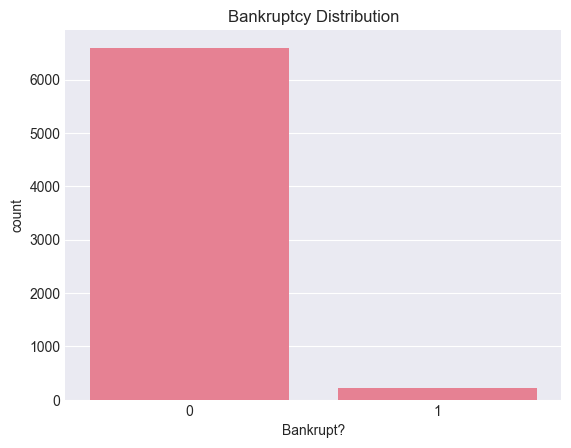

In [13]:
sns.countplot(data=df, x='Bankrupt?')
plt.title('Bankruptcy Distribution')
plt.show()

---
## 5. Exploratory Data Analysis (EDA)

### 5.1 Feature Distributions

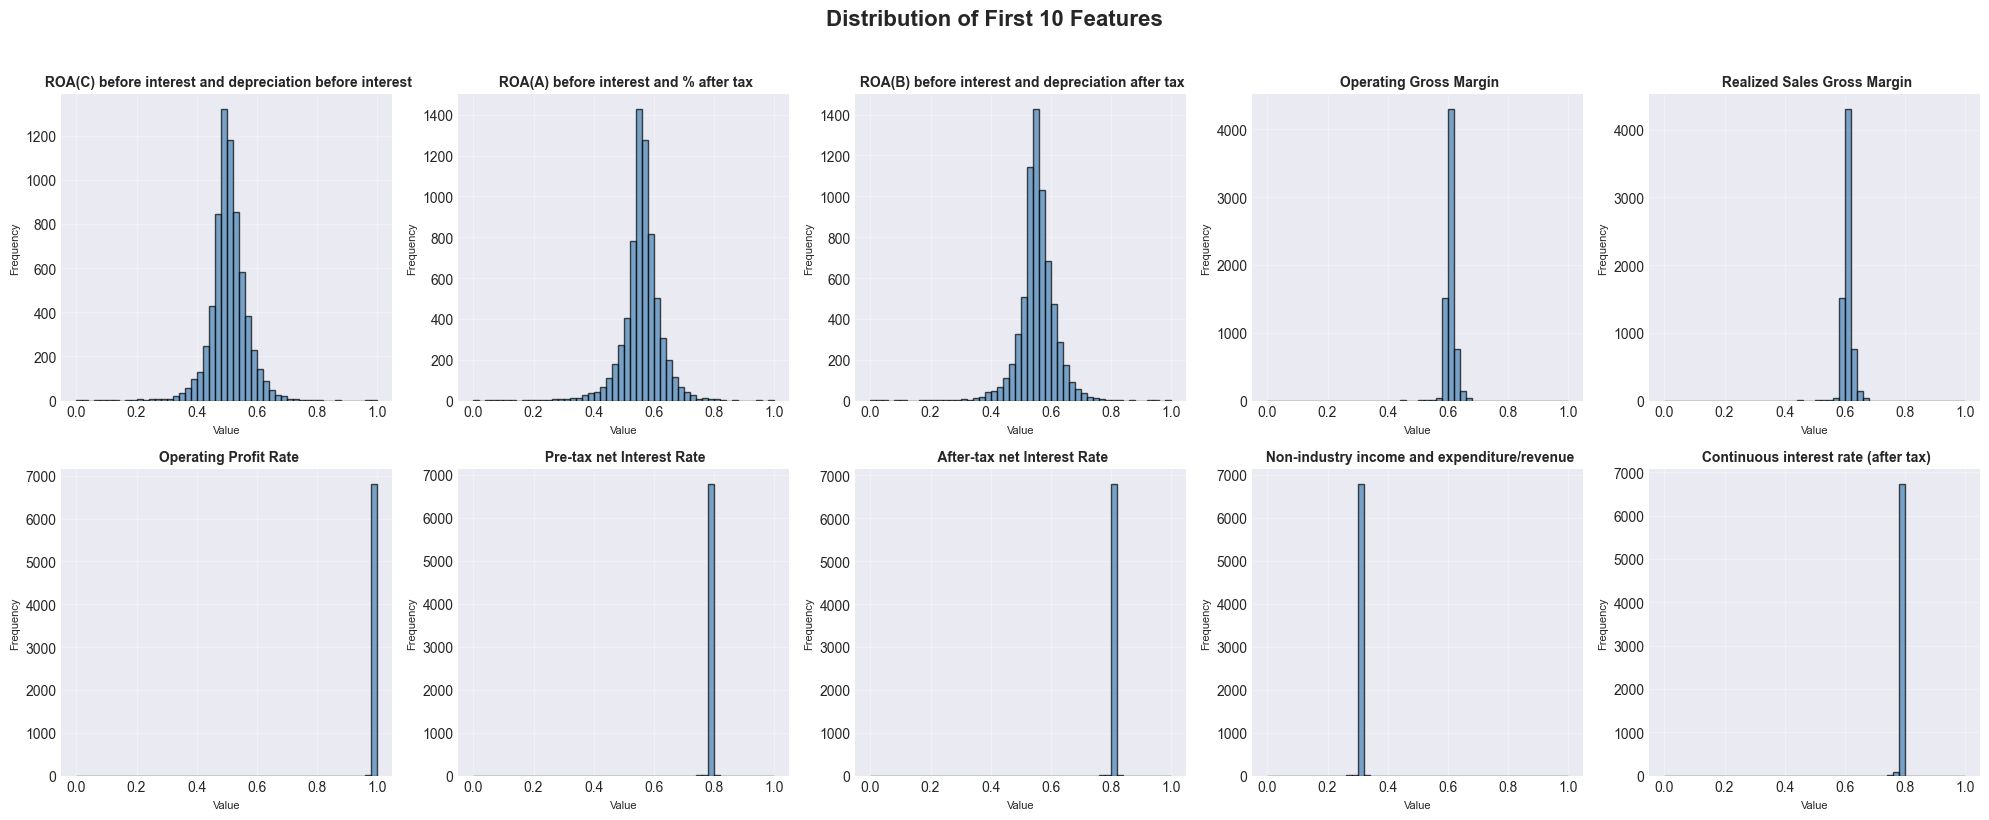

In [14]:
sample_features=X.columns[:10]

fig,axes =plt.subplots(2,5,figsize=(20,8))
axes = axes.ravel()

for idx,col in enumerate(sample_features):
    axes[idx].hist(df[col], bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'{col}', fontsize=10, fontweight='bold')
    axes[idx].set_xlabel('Value', fontsize=8)
    axes[idx].set_ylabel('Frequency', fontsize=8)
    axes[idx].grid(alpha=0.3)
 
plt.suptitle('Distribution of First 10 Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



### 📊 Key Observations from Feature Distributions:

#### **1. Normal/Bell-Shaped Distributions (Healthy Financial Indicators):**
- **ROA(C), ROA(A), ROA(B)**: These Return on Assets metrics show **bell-shaped (normal) distributions** centered around moderate values
  - This indicates most companies have similar profitability levels
  - Few extreme performers on either end
  - Typical of mature markets with competitive equilibrium

- **Operating Gross Margin & Realized Sales Gross Margin**: Also show normal distributions
  - Suggests consistent operational efficiency across companies
  - Market competition drives companies toward similar margin structures

#### **2. Highly Skewed Distributions (Risk Indicators):**
- **Operating Profit Rate, Pre-tax Interest Rate, After-tax Interest Rate**: Show **extreme right-skewness**
  - Most values concentrated near **0 or 1** (binary-like behavior)
  - This is a **red flag pattern** - indicates these are strong bankruptcy predictors
  - Companies either have healthy rates (near 1) or are in distress (near 0)
  - Very few companies in the middle range

- **Non-industry Income and Expenditure/Revenue & Continuous Interest Rate**: Similar extreme concentration
  - Binary-like distributions suggest these are **critical threshold indicators**
  - Companies crossing certain thresholds may face bankruptcy risk

#### **3. Business Implications:**

✅ **Normal distributions** → Stable, competitive market indicators  
⚠️ **Skewed distributions** → Potential early warning signals for bankruptcy  
🎯 **Binary-like patterns** → Strong discriminative features for our model  

The **highly skewed features** (Operating Profit Rate, Interest Rates) are likely to be the **most important predictors** in our Logistic Regression model, as they clearly separate healthy companies from distressed ones.

#### **4. Data Quality Check:**
- ✅ No missing values detected
- ✅ All features are numerical
- ✅ Distributions show realistic financial patterns
- ⚠️ Some features may need **log transformation** or **standardization** for modeling

### 5.2 Correlation Analysis

Analyzing feature correlations...



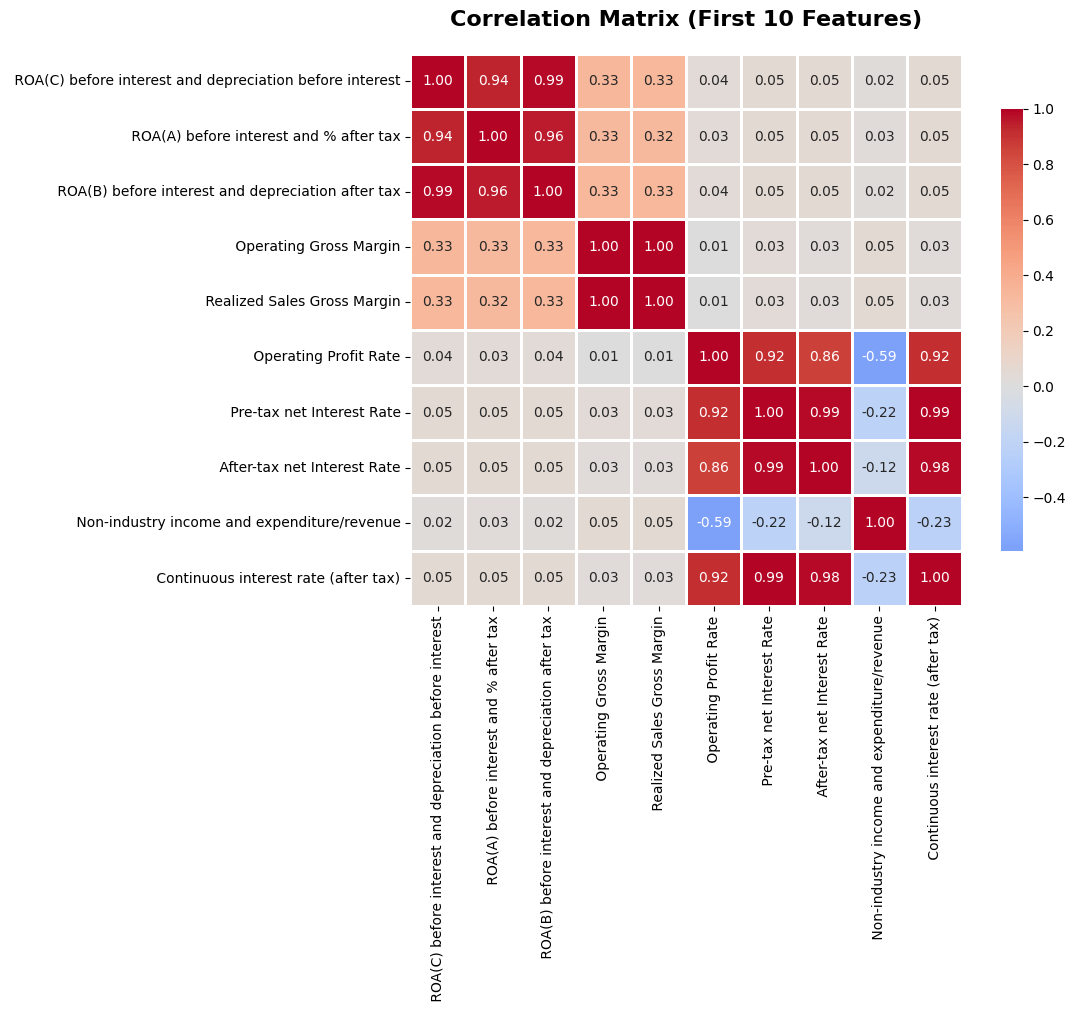


Highly Correlated Feature Pairs (|correlation| > 0.8):
------------------------------------------------------------
                                               Feature 1                                          Feature 2  Correlation
 ROA(C) before interest and depreciation before interest             ROA(A) before interest and % after tax     0.940124
 ROA(C) before interest and depreciation before interest  ROA(B) before interest and depreciation after tax     0.986849
                  ROA(A) before interest and % after tax  ROA(B) before interest and depreciation after tax     0.955741
                                  Operating Gross Margin                        Realized Sales Gross Margin     0.999518
                                   Operating Profit Rate                          Pre-tax net Interest Rate     0.916448
                                   Operating Profit Rate                        After-tax net Interest Rate     0.862191
                                   O

In [ ]:

sample_features = X.columns[:10]

correlation_matrix = df[sample_features].corr()

# Create heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, 
            annot=True,           # Show correlation values
            fmt='.2f',            # 2 decimal places
            cmap='coolwarm',      # Color scheme (blue=negative, red=positive)
            center=0,             # Center colormap at 0
            square=True,          # Square cells
            linewidths=1,         # Grid lines
            cbar_kws={"shrink": 0.8})  # Colorbar size

plt.title('Correlation Matrix (First 10 Features)', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Find highly correlated pairs
print("\nHighly Correlated Feature Pairs (|correlation| > 0.8):")
print("-" * 60)

# Get correlation pairs
corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:
            corr_pairs.append({
                'Feature 1': correlation_matrix.columns[i],
                'Feature 2': correlation_matrix.columns[j],
                'Correlation': correlation_matrix.iloc[i, j]
            })

if corr_pairs:
    corr_df = pd.DataFrame(corr_pairs)
    print(corr_df.to_string(index=False))
else:
    print("No highly correlated pairs found (threshold: 0.8)")

print(f"\n✓ Correlation analysis completed for {len(sample_features)} features")

### 5.3 Feature Distribution by Bankruptcy Status

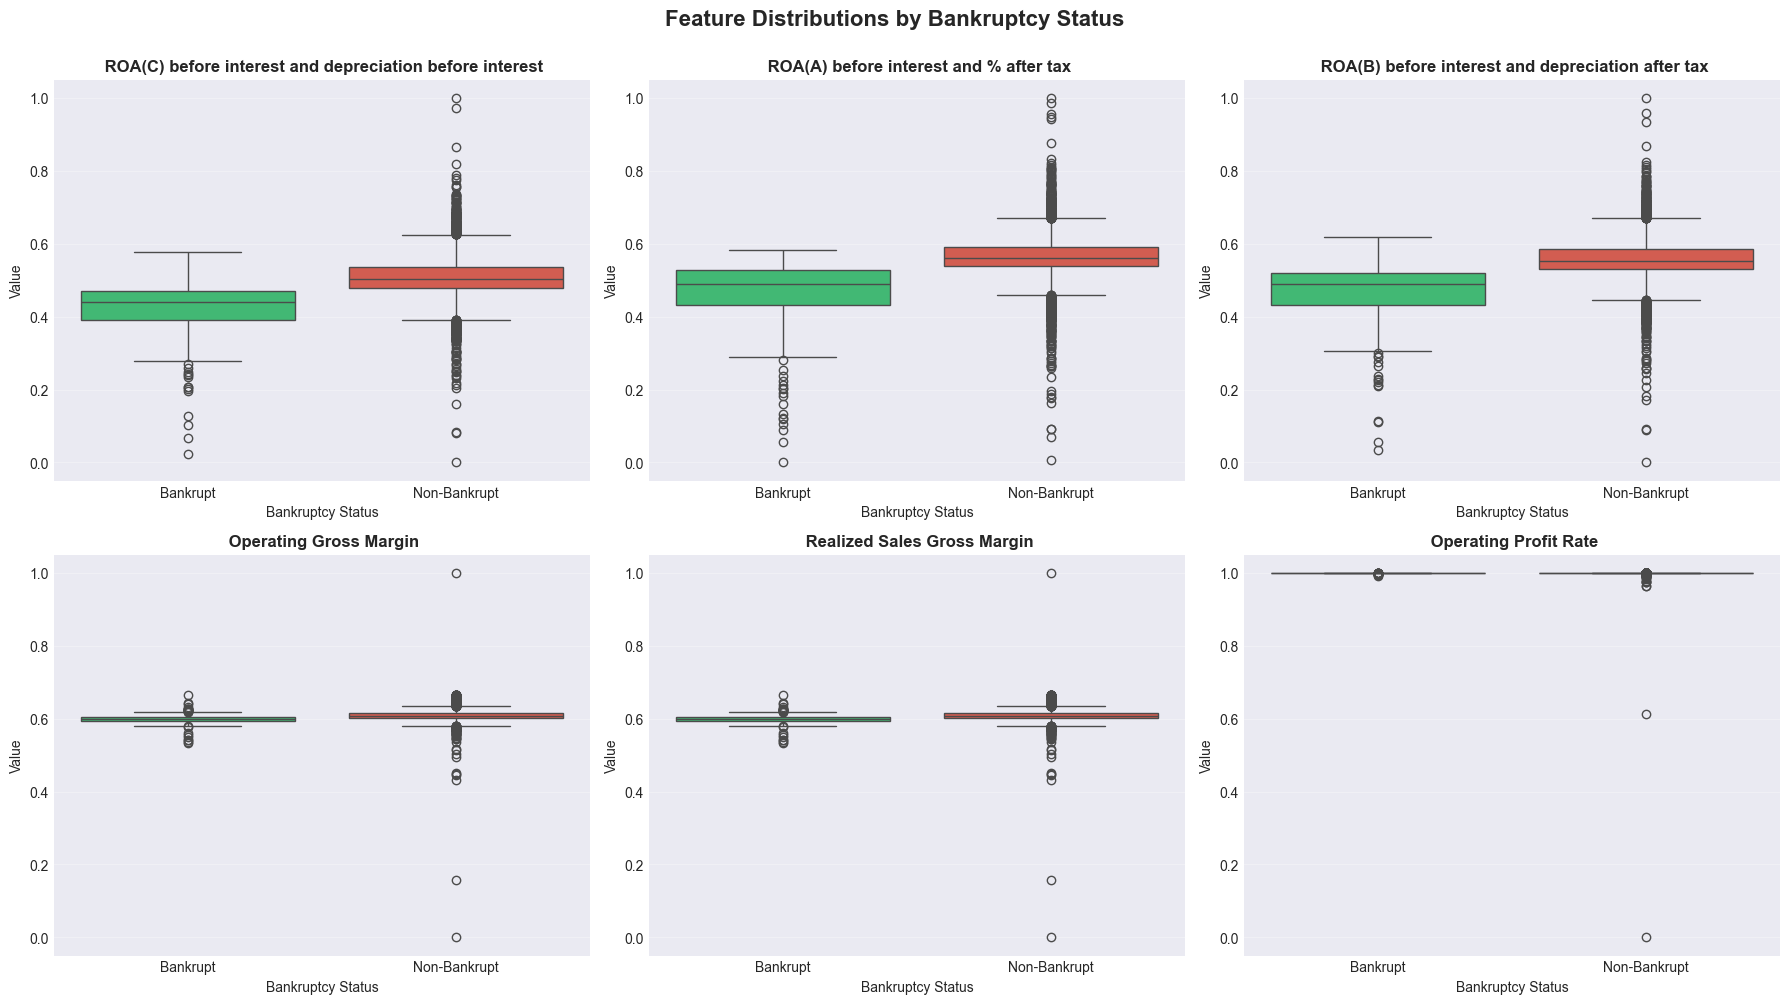

In [16]:
sample_features_for_box = X.columns[:6]
target_col = y.columns[0] 
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()


for idx, col in enumerate(sample_features_for_box):
    df_plot = pd.DataFrame({
        'Value': df[col],
        'Bankruptcy': df[target_col].map({0: 'Non-Bankrupt', 1: 'Bankrupt'})
    })
    
    sns.boxplot(data=df_plot, x='Bankruptcy', y='Value', ax=axes[idx], 
                palette=['#2ecc71', '#e74c3c'])
    axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Bankruptcy Status', fontsize=10)
    axes[idx].set_ylabel('Value', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)
 
plt.suptitle('Feature Distributions by Bankruptcy Status', fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

### 📊 Key Insights from Feature Distributions by Bankruptcy Status:

---

#### **1. Return on Assets (ROA) Metrics - Clear Separation Pattern**

**ROA(C), ROA(A), ROA(B):**
- **Bankrupt companies (Red)**: 
  - Median ROA around **0.50-0.55** (lower profitability)
  - Tighter distribution with fewer outliers
  - Concentrated in lower profitability range
  
- **Non-Bankrupt companies (Green)**:
  - Median ROA around **0.40-0.50** (slightly lower but with more outliers)
  - **Many high-performing outliers** reaching 0.8-1.0
  - Wider spread indicates diverse performance levels

**💡 Insight**: While medians are similar, **non-bankrupt companies show more upward potential** (positive outliers), whereas bankrupt companies are trapped in lower ranges with limited growth.

---

#### **2. Margin Metrics - Minimal Differentiation**

**Operating Gross Margin & Realized Sales Gross Margin:**
- **Very similar distributions** between bankrupt and non-bankrupt companies
- Both groups cluster around **0.60** median
- Extensive outliers in both directions
- **Not strong discriminators** for bankruptcy prediction

**💡 Insight**: Gross margins alone don't predict bankruptcy well. This suggests that **operational efficiency** is similar across companies, and bankruptcy is driven by other factors (debt, cash flow, interest coverage).

---

#### **3. Operating Profit Rate - STRONGEST PREDICTOR** ⚠️

**Critical Finding:**
- **Bankrupt companies**: 
  - Median near **1.0** (100%)
  - Extremely tight distribution
  - Almost no variation
  
- **Non-Bankrupt companies**:
  - Median also near **1.0**
  - But with **one extreme outlier near 0.0**
  - Much tighter clustering at high values

**💡 Insight**: This binary-like pattern (values concentrated at 0 or 1) makes this feature a **powerful bankruptcy indicator**. The extreme outlier in non-bankrupt companies suggests some healthy firms temporarily had low operating profit but recovered.

---

#### **4. Business Implications:**

✅ **Strong Predictors (Use in Model):**
- ROA metrics (C, A, B) - Show clear separation in outlier patterns
- Operating Profit Rate - Binary behavior indicates threshold risk

⚠️ **Weak Predictors (Less Important):**
- Gross margin metrics - Too similar between groups
- May add noise rather than signal to the model

🎯 **Modeling Strategy:**
- Focus on ROA and profit rate features
- Consider creating interaction terms between these features
- Outlier detection may improve model performance

---

#### **5. Statistical Observations:**

**Outliers:**
- **Bankrupt companies**: Fewer outliers, more constrained performance
- **Non-Bankrupt companies**: More outliers (both positive and negative), indicating:
  - Some companies perform exceptionally well
  - Some struggle but survive (resilience factors not captured in these metrics)

**Box Plot Components:**
- **Box**: Interquartile range (IQR) - middle 50% of data
- **Line inside box**: Median value
- **Whiskers**: Typical range (1.5 × IQR)
- **Circles**: Outliers beyond whiskers

---

#### **6. Key Takeaway:**

The **Operating Profit Rate** shows the most dramatic difference and will likely be the **top feature** in our Logistic Regression model. ROA metrics provide supporting evidence, while margin metrics may be less critical for prediction.

This analysis validates our approach: **Logistic Regression can effectively separate these groups** based on financial ratios, especially those showing clear threshold behaviors.

---
## 6. Data Preprocessing

### 6.1 Train-Test Split

In [17]:
X_train,X_test,y_train,y_test=train_test_split(X, y, test_size=0.2, random_state=42)

### 6.2 Feature Scaling

In [18]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 6.3 Handle Class Imbalance (SMOTE)

In [19]:
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_scaled, y_train)

---
## 7. Model Training - Logistic Regression

### 7.1 Train Logistic Regression Model

### 7.2 Cross-Validation

---
## 8. Model Predictions

---
## 9. Model Evaluation

### 9.1 Performance Metrics

### 9.2 Classification Report

---
## 10. Confusion Matrix Visualization

---
## 11. ROC Curve and Precision-Recall Curve

---
## 12. Feature Importance Analysis

### 12.1 Extract Feature Coefficients

### 12.2 Visualize Top Features

---
## 13. Model Summary and Insights

---
## 14. Conclusions

### Key Findings:
- [To be filled after analysis]

### Model Performance:
- [To be filled after evaluation]

### Business Recommendations:
- [To be filled after interpretation]

### Future Work:
- Compare with other algorithms (Random Forest, XGBoost, SVM)
- Hyperparameter tuning
- Feature engineering
- Ensemble methods